C:\Users\nikhi\AppData\Local\Temp\ipykernel_2836\1467650024.py:12: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


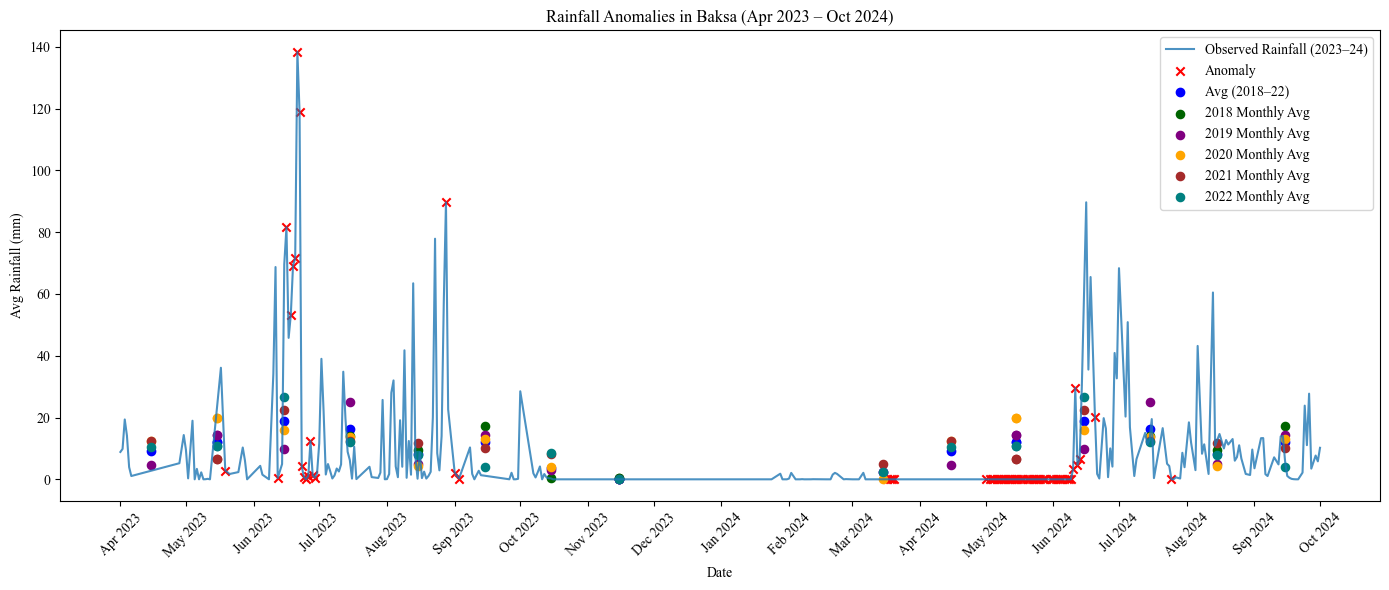

In [1]:
import pandas as pd
import numpy as np
from scipy.spatial import distance
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl

# Set global font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'

# Load dataset
df = pd.read_csv(
    r"C:\Users\nikhi\Desktop\Jupyter Notebook\ML_Rainfall\final_dataset_with_features.csv",
    parse_dates=["Date"]
)

# Focus on a specific district
district = "Baksa"
df = df[df['District'] == district].copy()
df.sort_values('Date', inplace=True)

# Add month and other required preprocessing
df['Month'] = df['Date'].dt.month

features = [
    'Avg_rainfall', 'Avg_smlvl_at15cm', 'Annual_Temp', 'Temp_Seasonal',
    'Rainfall_lag_1d', 'Rainfall_lag_3d', 'Rainfall_lag_7d',
    'Rainfall_7d_sum', 'Rainfall_7d_avg', 'SoilMoisture_7d_avg',
    'day_of_year', 'week_of_year', 'month_sin', 'month_cos'
]

df.dropna(subset=features, inplace=True)

# Split into train and test
train_df = df[df['Year'] <= 2022].copy()
test_df = df[df['Year'] >= 2023].copy()

X_train = train_df[features].values
X_test = test_df[features].values

# Mahalanobis setup
mean_vec = np.mean(X_train, axis=0)
cov_matrix = np.cov(X_train, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Compute distances
test_df['Mahalanobis_Distance'] = [
    distance.mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_test
]

train_distances = [distance.mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_train]
threshold = np.percentile(train_distances, 95)
test_df['Predicted_Anomaly'] = test_df['Mahalanobis_Distance'] > threshold

# Monthly average from train data (2018–22)
monthly_avg = df[df['Year'] < 2023].groupby('Month')['Avg_rainfall'].mean()
test_df['Monthly_Avg_Rainfall'] = test_df['Month'].map(monthly_avg)

# Filter anomalies
filtered_anomalies = test_df[test_df['Predicted_Anomaly']].copy()

# Monthly average by year (2018–2022)
monthly_by_year = (
    df[df['Year'].between(2018, 2022)]
    .groupby(['Year', 'Month'])['Avg_rainfall']
    .mean()
    .unstack(level=0)
)

# Include all months needed for plotting (Mar to Nov)
selected_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]
monthly_by_year = monthly_by_year.loc[selected_months]

# Prepare dates for plotting (15th of each selected month for both years)
plot_months = selected_months
plot_dates_2023 = pd.to_datetime([f"2023-{m:02d}-15" for m in plot_months])
plot_dates_2024 = pd.to_datetime([f"2024-{m:02d}-15" for m in plot_months])
all_plot_dates = list(plot_dates_2023) + list(plot_dates_2024)

# Repeat monthly_by_year to match dates
repeat_monthly = pd.concat([monthly_by_year]*2, ignore_index=True)
repeat_monthly['Date'] = all_plot_dates
repeat_monthly.set_index('Date', inplace=True)

# Monthly average (2018–22) as single series
monthly_avg_rainfall = pd.DataFrame({
    'Date': all_plot_dates,
    'Month': plot_months * 2
})
monthly_avg_rainfall['Monthly_Avg_Rainfall'] = monthly_avg_rainfall['Month'].map(monthly_avg)

# Time filtering
start_date = pd.to_datetime("2023-04-01")
end_date = pd.to_datetime("2024-10-01")

test_df = test_df[(test_df['Date'] >= start_date) & (test_df['Date'] <= end_date)]
filtered_anomalies = filtered_anomalies[(filtered_anomalies['Date'] >= start_date) & (filtered_anomalies['Date'] <= end_date)]
monthly_avg_rainfall = monthly_avg_rainfall[(monthly_avg_rainfall['Date'] >= start_date) & (monthly_avg_rainfall['Date'] <= end_date)]
repeat_monthly = repeat_monthly[(repeat_monthly.index >= start_date) & (repeat_monthly.index <= end_date)]

# ------------------- Plotting -------------------
plt.figure(figsize=(14, 6))

# Observed rainfall
plt.plot(test_df['Date'], test_df['Avg_rainfall'], label='Observed Rainfall (2023–24)', alpha=0.8)

# Anomalies
plt.scatter(filtered_anomalies['Date'], filtered_anomalies['Avg_rainfall'],
            color='red', marker='x', label='Anomaly')

# Monthly average (2018–22)
plt.scatter(monthly_avg_rainfall['Date'], monthly_avg_rainfall['Monthly_Avg_Rainfall'],
            color='blue', label='Avg (2018–22)', marker='o')

# Add specific monthly average points (May 2023, May 2024, Nov 2023)
extra_dates = pd.to_datetime(["2023-05-15", "2024-05-15", "2023-11-15"])
extra_months = [5, 5, 11]
extra_values = [monthly_avg[m] for m in extra_months]
plt.scatter(extra_dates, extra_values, color='blue', marker='o', s=35, label=None)

# Year-wise monthly averages (2018–2022)
colors = ['darkgreen', 'purple', 'orange', 'brown', 'teal']
year_color_map = dict(zip(range(2018, 2023), colors))
for i, year in enumerate(range(2018, 2023)):
    plt.scatter(repeat_monthly.index, repeat_monthly[year],
                label=f'{year} Monthly Avg', color=colors[i], marker='o', s=35)

# Plot each of May/Nov for each year separately
special_months = [5, 5, 11]
special_dates = pd.to_datetime(["2023-05-15", "2024-05-15", "2023-11-15"])
for year, color in year_color_map.items():
    for month, date in zip(special_months, special_dates):
        if month in monthly_by_year.index:
            val = monthly_by_year.loc[month, year]
            plt.scatter(date, val, color=color, marker='o', s=35, label=None)

# Formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.title(f"Rainfall Anomalies in {district} (Apr 2023 – Oct 2024)")
plt.xlabel("Date")
plt.ylabel("Avg Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()


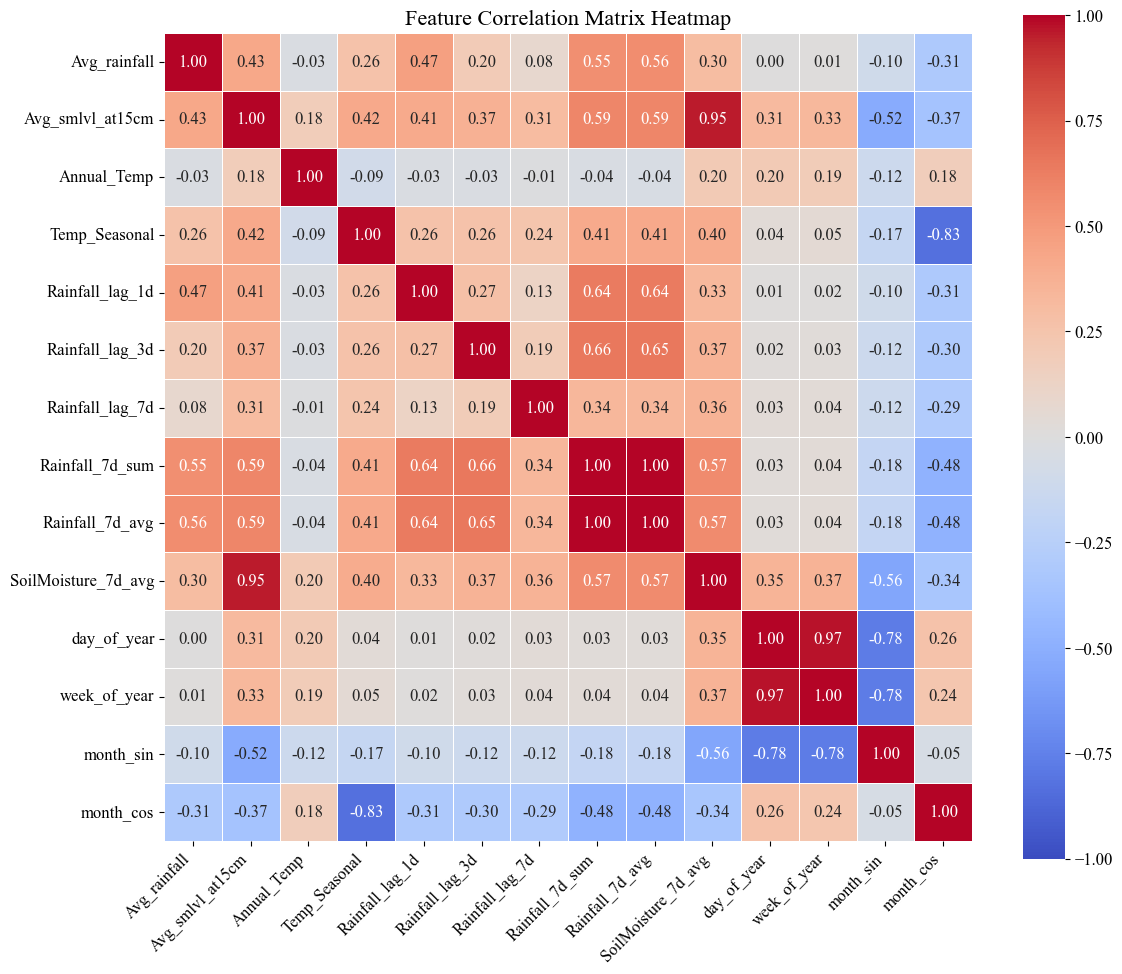

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. Set Times New Roman as the global font
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"] + mpl.rcParams.get("font.serif", [])
mpl.rcParams["font.size"] = 12  # Adjust as needed

# 2. Define the feature list
features = [
    'Avg_rainfall', 'Avg_smlvl_at15cm', 'Annual_Temp', 'Temp_Seasonal',
    'Rainfall_lag_1d', 'Rainfall_lag_3d', 'Rainfall_lag_7d',
    'Rainfall_7d_sum', 'Rainfall_7d_avg', 'SoilMoisture_7d_avg',
    'day_of_year', 'week_of_year', 'month_sin', 'month_cos'
]

# 3. Subset and clean the data
data = df[features].dropna()

# 4. Compute the Pearson correlation matrix
corr = data.corr()

# 5. Plot the heatmap in Times New Roman
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Feature Correlation Matrix Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
